In [1]:
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import pickle as pkl
import skimage
import yaml
from typing import Union, Optional, Type, Tuple, List, Dict
import sys
from skimage.color import label2rgb
import json
# import nrrd

import pandas as pd
import seaborn as sns
# Project Root
# used for searching packages and functions
# TODO: enter your project root dir here
ROOT_DIR = '/project/Xie_Lab/zgu/xiao_multiplex/multiTAP/image_cytof'

sys.path.append(ROOT_DIR)
sys.path.append(os.path.join(ROOT_DIR, 'image_cytof'))
from cytof.hyperion_preprocess import cytof_read_data_roi
from cytof.utils import save_multi_channel_img, check_feature_distribution
from cytof.classes import CytofImageTiff
from cytof.classes import CytofCohort


/project/Xie_Lab/zgu/conda_stuff/envs/cytof-shared/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

cell_type_cols = ['final_cell_type_B cells', 'final_cell_type_CD4',
       'final_cell_type_CD4 Treg', 'final_cell_type_CD8',
       'final_cell_type_Collagen CAF', 'final_cell_type_IDO_CD4',
       'final_cell_type_IDO_CD8', 'final_cell_type_IFN CAF',
       'final_cell_type_Ki67_CD4', 'final_cell_type_Ki67_CD8',
       'final_cell_type_PD1 CD4', 'final_cell_type_PDPN CAF',
       'final_cell_type_SMA CAF', 'final_cell_type_TCF1/7 CD4',
       'final_cell_type_TCF1/7 CD8', 'final_cell_type_dCAF',
       'final_cell_type_endothelial',
       'final_cell_type_high endothelial venules (HEV)',
       'final_cell_type_hypoxic CAF', 'final_cell_type_hypoxic tCAF',
       'final_cell_type_iCAF', 'final_cell_type_lymphatic endothelial',
       'final_cell_type_mCAF', 'final_cell_type_myeloid',
       'final_cell_type_neutrophils', 'final_cell_type_tCAF',
       'final_cell_type_vCAF']

BASE_CSV_DIR = "/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work"


# Figure 7b

In [3]:
accuml_type = 'sum'

# read in processed spatial interaction by cell type for each pt
spatial_pt_df = pd.read_csv(f"/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/nontumor_spatial_kneighbor15_{accuml_type}.csv", index_col=0)
n_roi = len(set(spatial_pt_df['roi_id']))
print(f"{n_roi} rois identified")

# set index as col
spatial_pt_df = spatial_pt_df.reset_index(names='cell_type')

# 0 is used to indicate not observed, but average over will skew the df
spatial_pt_df = spatial_pt_df.replace(0, np.nan)
spatial_pt_df

1950 rois identified


,cell_type,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,...,final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF,roi_id
0,final_cell_type_B cells,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,-0.640915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
1,final_cell_type_CD4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
2,final_cell_type_CD4 Treg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
3,final_cell_type_CD8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1
4,final_cell_type_Collagen CAF,NaN,NaN,NaN,NaN,1.060534,NaN,NaN,0.592758,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.450522,0.851875,NaN,NSCLC_ALL_175_A_A1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52645,final_cell_type_mCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9
52646,final_cell_type_myeloid,-0.260193,NaN,NaN,NaN,-0.291709,NaN,NaN,-0.223930,NaN,...,-0.915807,-0.361197,-0.209109,NaN,NaN,-0.075170,-0.464566,NaN,-0.221077,NSCLC_ALL_88_C_C8_9
52647,final_cell_type_neutrophils,-1.602241,NaN,NaN,NaN,-0.080989,NaN,NaN,NaN,NaN,...,-0.865892,-1.101215,NaN,NaN,NaN,-0.533646,0.285157,NaN,NaN,NSCLC_ALL_88_C_C8_9
52648,final_cell_type_tCAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NSCLC_ALL_88_C_C8_9


In [4]:
# average across patients for each cell type
grouped_spatial = spatial_pt_df.groupby(["cell_type"])[cell_type_cols].mean(numeric_only=False)

# now, fill na with 0 temprary (ideally separate out in the cluster maps)
grouped_spatial = grouped_spatial.fillna(0)
grouped_spatial

,final_cell_type_B cells,final_cell_type_CD4,final_cell_type_CD4 Treg,final_cell_type_CD8,final_cell_type_Collagen CAF,final_cell_type_IDO_CD4,final_cell_type_IDO_CD8,final_cell_type_IFN CAF,final_cell_type_Ki67_CD4,final_cell_type_Ki67_CD8,...,final_cell_type_high endothelial venules (HEV),final_cell_type_hypoxic CAF,final_cell_type_hypoxic tCAF,final_cell_type_iCAF,final_cell_type_lymphatic endothelial,final_cell_type_mCAF,final_cell_type_myeloid,final_cell_type_neutrophils,final_cell_type_tCAF,final_cell_type_vCAF
cell_type,,,,,,,,,,,,,,,,,,,,,
final_cell_type_B cells,0.120760,-0.353689,-0.333812,-0.411557,-0.578734,-0.383096,-0.338713,-0.468757,-0.378084,-0.392399,...,-0.088090,-0.595579,-0.385083,-0.519005,-0.271745,-0.503784,-0.503889,-0.533653,-0.436479,-0.545716
final_cell_type_CD4,-0.329419,0.044781,0.084704,-0.227167,-0.364911,0.276416,0.139322,-0.252190,0.140203,0.227542,...,0.751367,-0.450045,-0.195367,0.097397,0.355519,-0.001091,-0.217764,-0.313523,0.013453,-0.340711
final_cell_type_CD4 Treg,-0.317525,0.061186,0.160752,-0.214597,-0.374036,0.267107,0.223684,-0.176869,0.137894,0.105624,...,0.297685,-0.303730,-0.023796,-0.180957,0.174959,-0.153978,-0.206575,-0.260678,0.065253,-0.251920
final_cell_type_CD8,-0.411295,-0.242848,-0.220180,-0.236757,-0.565761,-0.205853,-0.201209,-0.391410,-0.209826,-0.277842,...,-0.057304,-0.612011,-0.435355,-0.455765,-0.308783,-0.430984,-0.405476,-0.548070,-0.400176,-0.512043
final_cell_type_Collagen CAF,-0.562242,-0.335982,-0.374627,-0.548559,0.021799,-0.313159,-0.466698,-0.566618,-0.321002,-0.361396,...,-0.236675,-0.531750,-0.377760,-0.462152,-0.291442,-0.378931,-0.473776,-0.368995,-0.411146,-0.516944
final_cell_type_IDO_CD4,-0.394888,0.315769,0.227582,-0.189147,-0.319520,0.350992,0.456968,0.010906,0.358039,-0.072079,...,0.325462,-0.218733,0.094944,0.094946,0.198661,0.125879,-0.143629,-0.148035,-0.096410,-0.148679
final_cell_type_IDO_CD8,-0.339452,0.370024,0.194291,-0.201122,-0.480985,0.456557,0.201486,0.036314,0.161678,0.027205,...,0.000000,-0.523269,-0.288123,-0.047264,0.322074,-0.103566,-0.251047,-0.240965,0.021155,-0.268586
final_cell_type_IFN CAF,-0.450972,-0.273603,-0.169202,-0.382917,-0.568623,0.010019,0.036871,0.161135,-0.102223,-0.323848,...,0.390168,-0.584857,-0.405270,-0.359663,-0.080978,-0.369227,-0.424871,-0.370472,-0.341131,-0.459850
final_cell_type_Ki67_CD4,-0.428872,0.092203,0.143139,-0.172446,-0.315784,0.282404,-0.057452,-0.172693,0.233694,0.333971,...,0.692187,-0.078684,0.620149,-0.176917,0.497761,-0.041774,-0.210334,-0.196733,0.120139,-0.225198


In [5]:
# clean up cell type names
clean_spatial_names = [cell_type.replace('final_cell_type_', '') for cell_type in grouped_spatial.columns]

# for better spacing
clean_spatial_names =  [cell_type.replace('high endothelial venules (HEV)', 'HEV') for cell_type in clean_spatial_names]
clean_spatial_names

['B cells',
 'CD4',
 'CD4 Treg',
 'CD8',
 'Collagen CAF',
 'IDO_CD4',
 'IDO_CD8',
 'IFN CAF',
 'Ki67_CD4',
 'Ki67_CD8',
 'PD1 CD4',
 'PDPN CAF',
 'SMA CAF',
 'TCF1/7 CD4',
 'TCF1/7 CD8',
 'dCAF',
 'endothelial',
 'HEV',
 'hypoxic CAF',
 'hypoxic tCAF',
 'iCAF',
 'lymphatic endothelial',
 'mCAF',
 'myeloid',
 'neutrophils',
 'tCAF',
 'vCAF']

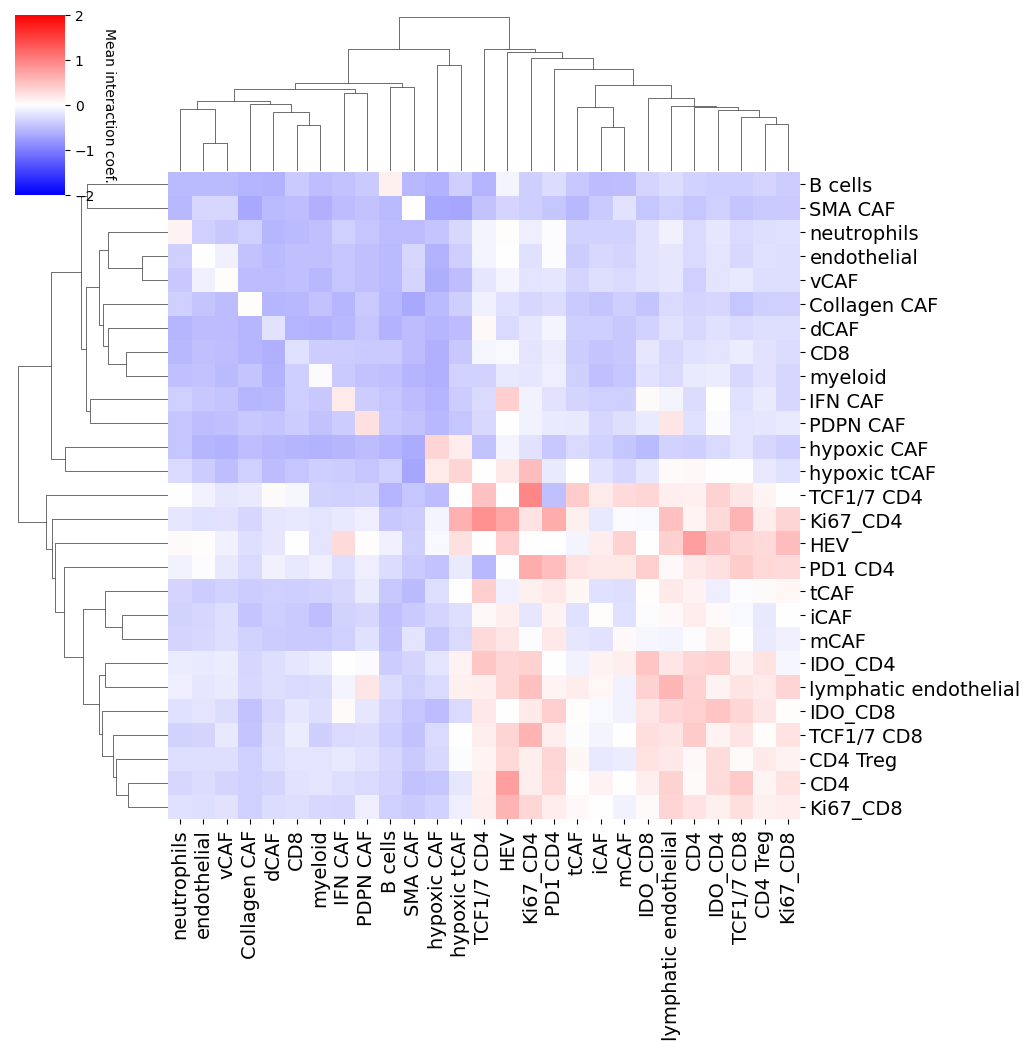

In [6]:

%matplotlib inline
epsilon = 1e-6

clustergrid = sns.clustermap(grouped_spatial,
                            center=np.log10(1 + epsilon), cmap='bwr', vmin=-2, vmax=2,
                            xticklabels=clean_spatial_names, yticklabels=clean_spatial_names)


# Remove y-axis label (index name from pandas DataFrame)
clustergrid.ax_heatmap.set_ylabel("")
clustergrid.ax_heatmap.set_xticklabels(clustergrid.ax_heatmap.get_xmajorticklabels(), fontsize=14)
clustergrid.ax_heatmap.set_yticklabels(clustergrid.ax_heatmap.get_ymajorticklabels(), fontsize=14)
# clustergrid.cax.tick_params(labelsize=22)


# Add label to colorbar
clustergrid.cax.set_ylabel("Mean interaction coef.", rotation=270, labelpad=15)

# plt.savefig(os.path.join(BASE_CSV_DIR, 'figure_7b.pdf'), format='pdf', dpi=300)
plt.show()

# Figure 7c

In [7]:
from statsmodels.stats.multitest import multipletests

def flatten_interaction_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flattens a non-symmetric spatial interaction matrix into a single-row
    wide-format DataFrame. Each column is a directional pair (e.g., 'GeneA_to_GeneB').

    Parameters:
        df (pd.DataFrame): A square DataFrame of spatial interaction values.

    Returns:
        pd.DataFrame: A single-row wide-format DataFrame with directional interaction pairs.
    """
    if df.shape[0] != df.shape[1]:
        raise ValueError("Input DataFrame must be square.")
    if not df.columns.equals(df.index):
        raise ValueError("DataFrame must have matching row and column labels.")

    colnames = [f"{row}_to_{col}" for row in df.index for col in df.columns]
    values = df.values.flatten()

    return pd.DataFrame([values], columns=colnames)

def extract_roi_id(roi_id):
    try:

        # first split by _
        split = roi_id.split('_')
        # special case for 178 A and C
        if roi_id.startswith('178_A') or roi_id.startswith('178_C'):
            return f"{split[0]}_{split[2]}{split[3]},{split[4]}"
        elif roi_id.startswith('178_B'): # special case for 178 B
            return f"{split[0]}_{split[3]}{split[4]},{split[5]}"
        else: # all other cases
            return f"{split[0]}_{split[2]},{split[3]}"
    except IndexError:
        return None  # or raise an error / return roi_id unchanged


In [8]:
# flatten out the interaction first
roi_ids = np.unique(spatial_pt_df['roi_id'])
print(f"{len(roi_ids)} ROIs identified")
flat_marker_roi_list = list()

for roi_id in roi_ids:

    try:
        one_spatial_mat = spatial_pt_df[spatial_pt_df['roi_id']==roi_id]

        # setup for flatten
        one_spatial_mat = one_spatial_mat.set_index('cell_type')
        one_spatial_mat = one_spatial_mat.drop(columns='roi_id')

        flat_edge_perc_remapped = flatten_interaction_matrix(one_spatial_mat)
        flat_edge_perc_remapped['ROI_ID'] = roi_id

        flat_marker_roi_list.append(flat_edge_perc_remapped)
    except Exception as e:
        print(f"ROI {roi_id} not processed due to error {e}")


combined_df = pd.concat(flat_marker_roi_list, axis=0, ignore_index=True)



1950 ROIs identified


In [38]:
# add the clinical data
pt_clinical_data = pd.read_csv('/project/Xie_Lab/zgu/xiao_multiplex/nsclc_multiTAP_work/clinical_data_ROI.csv')
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique patients")

# # remove NA and neoadjuvant therapy
pt_clinical_data = pt_clinical_data[~pt_clinical_data['NeoAdj'].isna()]
pt_clinical_data = pt_clinical_data[pt_clinical_data['NeoAdj']!='NeoAdjuvantTherapy'].reset_index(drop=True) # exclude NeoAdjuvantTherapy, see original paper
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique patients")

pt_clinical_data = pt_clinical_data[['RoiID', 'Patient_ID', 'OS', 'DFS', 'Ev.O']]

# # remove duplicates after subsetting for pt and survival info
pt_clinical_data = pt_clinical_data.drop_duplicates(keep='first').reset_index(drop=True)
print(f"{len(set(pt_clinical_data['Patient_ID']))} unique patients")

pt_clinical_data

1071 unique patients
959 unique patients
959 unique patients


,RoiID,Patient_ID,OS,DFS,Ev.O
0,"175_A1,1",175_1,254.0,NaN,1.0
1,"175_A1,2",175_5,3420.0,3420.0,1.0
2,"175_A1,3",175_9,1312.0,1312.0,1.0
3,"175_A1,4",175_13,1950.0,1950.0,1.0
4,"175_A1,6",175_21,820.0,820.0,1.0
...,...,...,...,...,...
1785,"88_C8,9",88_521,596.0,370.0,1.0
1786,"88_C8,10",88_525,323.0,323.0,1.0
1787,"88_C8,11",88_529,1707.0,1707.0,0.0
1788,"88_C8,12",88_533,1652.0,1652.0,0.0


In [37]:
# first strip the NSCLC_ALL, then map the ROI ID to clinical file format
combined_df['roi_mappable'] = combined_df['ROI_ID'].str.replace('NSCLC_ALL_', '').apply(extract_roi_id)
spatial_clinical_merged = combined_df.merge(pt_clinical_data, how='inner', left_on='roi_mappable', right_on='RoiID')
print("number of unique patients:", spatial_clinical_merged['Patient_ID'].nunique())

# # exclude pt where OS, outcome is unavailable
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['OS'].isna()].reset_index(drop=True)
spatial_clinical_merged = spatial_clinical_merged[~spatial_clinical_merged['Ev.O'].isna()].reset_index(drop=True)
print("number of unique patients:", spatial_clinical_merged['Patient_ID'].nunique())
spatial_clinical_merged

number of unique patients: 956
number of unique patients: 953


,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,final_cell_type_B cells_to_final_cell_type_Ki67_CD8,...,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,ROI_ID,roi_mappable,RoiID,Patient_ID,OS,DFS,Ev.O
0,0.130844,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,NaN,...,NaN,NaN,NaN,NSCLC_ALL_175_A_A1_1,"175_A1,1","175_A1,1",175_1,254.0,NaN,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.064503,0.673285,NSCLC_ALL_175_A_A1_10,"175_A1,10","175_A1,10",175_37,3454.0,3454.0,1.0
2,NaN,NaN,NaN,NaN,0.163243,NaN,NaN,NaN,NaN,NaN,...,-1.363546,NaN,0.389697,NSCLC_ALL_175_A_A1_11,"175_A1,11","175_A1,11",175_41,290.0,261.0,1.0
3,-0.224310,NaN,NaN,NaN,-0.394078,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.228058,NSCLC_ALL_175_A_A1_12,"175_A1,12","175_A1,12",175_45,1649.0,1649.0,1.0
4,-0.263809,NaN,NaN,-0.443824,NaN,NaN,NaN,NaN,NaN,-0.506835,...,0.220689,NaN,0.088272,NSCLC_ALL_175_A_A1_13,"175_A1,13","175_A1,13",175_49,273.0,273.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1750,NaN,NaN,NaN,1.066596,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.532252,NaN,0.109439,NSCLC_ALL_88_C_C8_2,"88_C8,2","88_C8,2",88_493,338.0,338.0,1.0
1751,1.204031,NaN,NaN,NaN,NaN,NaN,NaN,-1.465734,NaN,NaN,...,-0.440778,-0.341862,-0.171346,NSCLC_ALL_88_C_C8_3,"88_C8,3","88_C8,3",88_497,1350.0,537.0,1.0
1752,1.243490,NaN,NaN,NaN,NaN,NaN,NaN,0.552815,NaN,NaN,...,-0.666777,-0.399732,-0.377598,NSCLC_ALL_88_C_C8_4,"88_C8,4","88_C8,4",88_501,1848.0,1848.0,0.0
1753,NaN,NaN,NaN,NaN,-0.522795,NaN,NaN,NaN,NaN,NaN,...,-0.570147,NaN,-0.414905,NSCLC_ALL_88_C_C8_5,"88_C8,5","88_C8,5",88_505,688.0,504.0,1.0


In [39]:
# get the marker and survival columns
marker_cols = list(spatial_clinical_merged.columns[spatial_clinical_merged.columns.str.contains('final_cell_type')])
keep_cols = marker_cols + ['OS', 'Ev.O', 'Patient_ID']

# subsetting needed columns only
spatial_clinical_for_survival = spatial_clinical_merged[keep_cols]

# previously checked that each pt_id has consistent survival info
spatial_clinical_for_survival = spatial_clinical_for_survival.groupby('Patient_ID').mean().reset_index()
spatial_clinical_for_survival

,Patient_ID,final_cell_type_B cells_to_final_cell_type_B cells,final_cell_type_B cells_to_final_cell_type_CD4,final_cell_type_B cells_to_final_cell_type_CD4 Treg,final_cell_type_B cells_to_final_cell_type_CD8,final_cell_type_B cells_to_final_cell_type_Collagen CAF,final_cell_type_B cells_to_final_cell_type_IDO_CD4,final_cell_type_B cells_to_final_cell_type_IDO_CD8,final_cell_type_B cells_to_final_cell_type_IFN CAF,final_cell_type_B cells_to_final_cell_type_Ki67_CD4,...,final_cell_type_vCAF_to_final_cell_type_hypoxic tCAF,final_cell_type_vCAF_to_final_cell_type_iCAF,final_cell_type_vCAF_to_final_cell_type_lymphatic endothelial,final_cell_type_vCAF_to_final_cell_type_mCAF,final_cell_type_vCAF_to_final_cell_type_myeloid,final_cell_type_vCAF_to_final_cell_type_neutrophils,final_cell_type_vCAF_to_final_cell_type_tCAF,final_cell_type_vCAF_to_final_cell_type_vCAF,OS,Ev.O
0,175_1,0.168452,NaN,NaN,NaN,NaN,NaN,NaN,-0.018393,NaN,...,NaN,0.368047,NaN,-0.467787,-0.572954,NaN,NaN,-0.494354,254.0,1.0
1,175_10,0.124939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.442446,NaN,-0.189984,-0.302291,-1.296232,-0.673553,-0.206097,1134.0,1.0
2,175_100,0.301903,NaN,-0.121964,-0.554866,-0.596081,-0.096762,-0.632213,-0.104330,-0.01922,...,0.116051,NaN,-0.06198,-0.487861,-0.536280,-0.243848,0.132672,0.019130,490.0,1.0
3,175_101,0.342103,NaN,NaN,NaN,-0.614548,NaN,NaN,-0.794573,NaN,...,NaN,-0.213500,NaN,-0.627966,0.076574,NaN,NaN,0.109901,1930.0,1.0
4,175_102,0.251555,NaN,NaN,NaN,NaN,NaN,NaN,-0.617567,NaN,...,NaN,-0.604280,NaN,NaN,0.070883,-0.096921,-1.073562,0.201454,794.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,88_533,-0.033216,NaN,NaN,NaN,-0.973724,0.578830,NaN,NaN,NaN,...,NaN,NaN,0.35046,NaN,-0.245520,-0.123012,NaN,0.260963,1652.0,0.0
949,88_534,-0.093204,NaN,NaN,-0.344663,-0.550429,NaN,NaN,-0.394401,NaN,...,NaN,NaN,NaN,-0.136397,-0.808219,NaN,NaN,-0.440283,368.0,1.0
950,88_535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.610603,NaN,NaN,0.082690,1240.0,1.0
951,88_536,0.401673,NaN,NaN,NaN,-0.906485,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.015462,-0.410854,-1.187941,-0.591622,-0.084282,201.0,1.0


In [40]:
from lifelines.statistics import logrank_test, multivariate_logrank_test

# split patients into interaction pair sig. high vs. low
results = []
total_pt = len(spatial_clinical_for_survival)
minimum_pt_thresh = 10 # need at least 10 pt to continue the KM curve

# for each co-exp feature
for feature in marker_cols:
    km_cols = [feature] + ['OS', 'Ev.O', 'Patient_ID']
    km_df = spatial_clinical_for_survival[km_cols].copy()

    # count # of pt with NAs in the pair
    na_counts =  km_df[feature].isna().sum()
    if (total_pt - na_counts) <= minimum_pt_thresh: continue

    # stratify by expression
    median_exp = km_df[feature].median()
    km_df['exp_group'] = np.where(km_df[feature] > median_exp, 'high', 'low')
    
    
    logrank_res = logrank_test(km_df[km_df['exp_group']=='low']['OS'], km_df[km_df['exp_group']=='high']['OS'],
                        event_observed_A=km_df[km_df['exp_group']=='low']['Ev.O'], event_observed_B=km_df[km_df['exp_group']=='high']['Ev.O'])
    
    p_value = logrank_res.p_value
    results.append({'feature': feature, 'pval': p_value})

results_df = pd.DataFrame(results)
results_df['pval_adj'] = multipletests(results_df['pval'], method='fdr_bh')[1]


In [41]:
# display the df
pvalues = results_df['pval']
pvals_fdr = results_df['pval_adj']
results_df.sort_values(by='pval')


,feature,pval,pval_adj
489,final_cell_type_mCAF_to_final_cell_type_iCAF,0.000062,0.036985
445,final_cell_type_iCAF_to_final_cell_type_mCAF,0.000199,0.059540
407,final_cell_type_hypoxic tCAF_to_final_cell_typ...,0.000512,0.101889
443,final_cell_type_iCAF_to_final_cell_type_iCAF,0.000893,0.133317
165,final_cell_type_IFN CAF_to_final_cell_type_B c...,0.001879,0.224412
...,...,...,...
94,final_cell_type_CD8_to_final_cell_type_myeloid,0.991266,0.996660
87,final_cell_type_CD8_to_final_cell_type_dCAF,0.993950,0.996660
201,final_cell_type_Ki67_CD4_to_final_cell_type_dCAF,0.994840,0.996660
244,final_cell_type_PDPN CAF_to_final_cell_type_CD4,0.994990,0.996660


In [42]:
best_col = "final_cell_type_mCAF_to_final_cell_type_iCAF"
km_cols = [best_col] + ['OS', 'Ev.O', 'Patient_ID']
km_df = spatial_clinical_for_survival[km_cols]

# stratify by expression
median_exp = km_df[best_col].median()
km_df['exp_group'] = np.where(km_df[best_col] > median_exp, 'high', 'low')

km_df

/tmp/ipykernel_1091515/2712946117.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  km_df['exp_group'] = np.where(km_df[best_col] > median_exp, 'high', 'low')


,final_cell_type_mCAF_to_final_cell_type_iCAF,OS,Ev.O,Patient_ID,exp_group
0,0.393767,254.0,1.0,175_1,high
1,-0.318465,1134.0,1.0,175_10,low
2,NaN,490.0,1.0,175_100,low
3,-0.832124,1930.0,1.0,175_101,low
4,0.055133,794.0,1.0,175_102,high
...,...,...,...,...,...
948,NaN,1652.0,0.0,88_533,low
949,NaN,368.0,1.0,88_534,low
950,NaN,1240.0,1.0,88_535,low
951,NaN,201.0,1.0,88_536,low


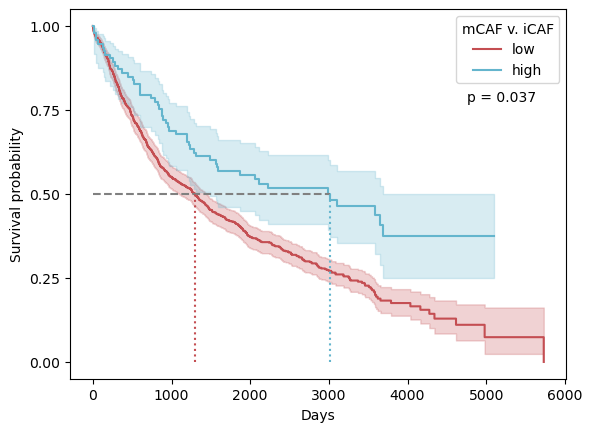

In [ ]:
from lifelines import KaplanMeierFitter

# dichotomized groups 
kmf = KaplanMeierFitter()
kmf.fit(durations=km_df[km_df['exp_group']=='low']['OS'], event_observed=km_df[km_df['exp_group']=='low']['Ev.O'], label='low')
ax = kmf.plot(c=sns.color_palette('deep')[3])
low_median = kmf.median_survival_time_


kmf.fit(durations=km_df[km_df['exp_group']=='high']['OS'], event_observed=km_df[km_df['exp_group']=='high']['Ev.O'], label='high')
kmf.plot(ax=ax, c=sns.color_palette('deep')[9])

results = logrank_test(km_df[km_df['exp_group']=='low']['OS'], km_df[km_df['exp_group']=='high']['OS'],
                       event_observed_A=km_df[km_df['exp_group']=='low']['Ev.O'], event_observed_B=km_df[km_df['exp_group']=='high']['Ev.O'])
high_median = kmf.median_survival_time_


# # from the log-rank test
p_value = results.p_value

# Vertical lines at median survival times
ax.hlines(0.5, xmin=0, xmax=max(low_median, high_median), ls='--', color='gray')
if low_median is not None:
    ax.vlines(low_median, ymin=0, ymax=0.5, ls=':', color=sns.color_palette('deep')[3])

if high_median is not None:
    ax.vlines(high_median, ymin=0, ymax=0.5, ls=':', color=sns.color_palette('deep')[9])

# Customize the plot
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.text(0.8, 0.75, f'p = {0.037}', transform=ax.transAxes)
plt.xlabel('Days')
plt.ylabel('Survival probability')
plt.legend(title="mCAF v. iCAF")
# plt.savefig(os.path.join(BASE_CSV_DIR, 'figure_7c.pdf'), format='pdf',dpi=300)
plt.show()